In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('BlackFriday.csv')

In [4]:
df.shape

(537577, 12)

In [5]:
df.isna().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                           0
dtype: int64

In [6]:
del df['Product_Category_2']
del df['Product_Category_3']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537577 entries, 0 to 537576
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     537577 non-null  int64 
 1   Product_ID                  537577 non-null  object
 2   Gender                      537577 non-null  object
 3   Age                         537577 non-null  object
 4   Occupation                  537577 non-null  int64 
 5   City_Category               537577 non-null  object
 6   Stay_In_Current_City_Years  537577 non-null  object
 7   Marital_Status              537577 non-null  int64 
 8   Product_Category_1          537577 non-null  int64 
 9   Purchase                    537577 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 41.0+ MB


### Analyzing Column

In [8]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [9]:
df['User_ID'].nunique()  ## there are 5891 users 

5891

In [10]:
df['Product_ID'].nunique()  ## there are 3623 unique products 

3623

In [11]:
df['Age'].unique()  ## there are total 7 age groups involved in this

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [12]:
df['Occupation'].nunique() ## therefore customers are from 21 unique occupations

21

In [13]:
df['City_Category'].unique()  ## 3 categories of city

array(['A', 'C', 'B'], dtype=object)

In [14]:
df['Stay_In_Current_City_Years'].unique() ## 5 unique values 

array(['2', '4+', '3', '1', '0'], dtype=object)

In [15]:
df_purchases = df.groupby(by='User_ID')['Purchase'].sum()  

In [16]:
df_purchases.values.sum()/len(df_purchases)  ## average purchase by an user 

851751.5494822611

## Analysing gender

In [17]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [18]:
df[df['Gender']=='M']['User_ID'].nunique() ## no. of male customers

4225

In [19]:
df[df['Gender']=='F']['User_ID'].nunique() ## no. of female customer 

1666

In [20]:
Gender_data = pd.DataFrame({'Count' :[df[df['Gender']=='M']['User_ID'].nunique() , df[df['Gender']=='F']['User_ID'].nunique()]} , index=['Male' , 'Female'])

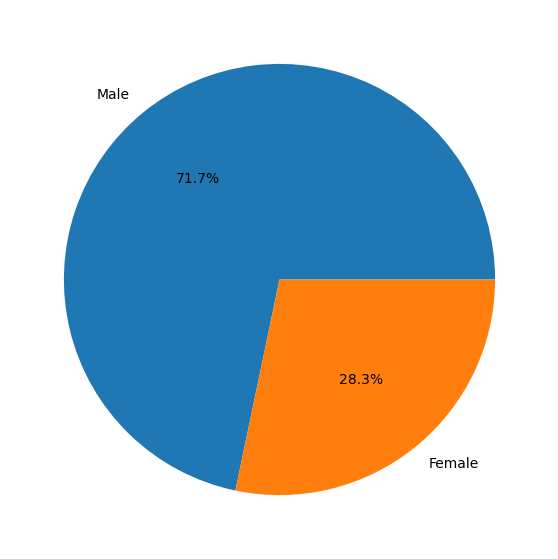

In [21]:
plt.figure(figsize=(7,7))
plt.pie(Gender_data['Count'] ,autopct='%.1f%%' , labels=Gender_data.index)
plt.show()

### Approach 2

In [22]:
df.groupby('Gender')['User_ID'].nunique()

Gender
F    1666
M    4225
Name: User_ID, dtype: int64

<Axes: ylabel='User_ID'>

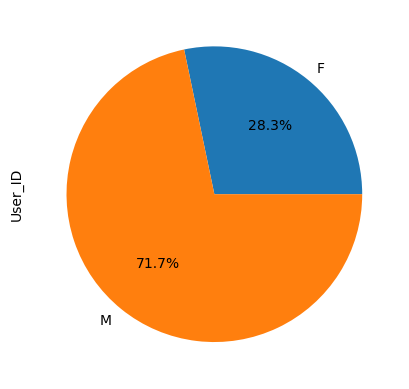

In [23]:
df.groupby('Gender')['User_ID'].nunique().plot(kind='pie' , autopct = '%.1f%%')

### amount they have have spent 

In [24]:
df.groupby('Gender')['Purchase'].sum()

Gender
F    1164624021
M    3853044357
Name: Purchase, dtype: int64

<Axes: ylabel='Purchase'>

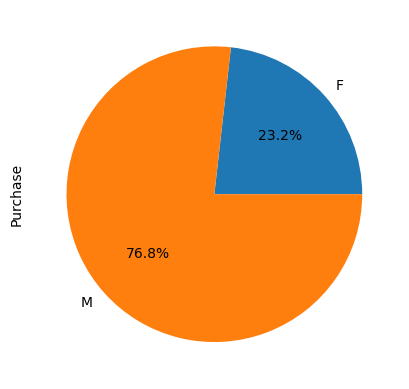

In [25]:
df.groupby('Gender')['Purchase'].sum().plot(kind='pie' , autopct='%.1f%%')

In [26]:
df.groupby('Gender')['Purchase'].mean()

Gender
F    8809.761349
M    9504.771713
Name: Purchase, dtype: float64

<Axes: xlabel='Gender', ylabel='Average_purchase'>

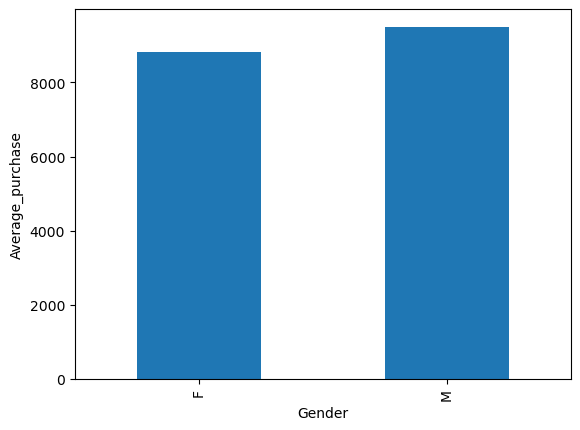

In [27]:
df.groupby('Gender')['Purchase'].mean().plot(kind='bar' , ylabel='Average_purchase')

The analysis shows that male customers contribute approximately 76.8% of total Black Friday sales, while female customers contribute 23.2%. Additionally, the average purchase amount for males (₹9504) is slightly higher than females (₹8809). This suggests that males not only shop more frequently but also spend marginally more per transaction.

# Analysing Age & marital status 

In [28]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [29]:
df.groupby('Age')['Purchase'].size()

Age
0-17      14707
18-25     97634
26-35    214690
36-45    107499
46-50     44526
51-55     37618
55+       20903
Name: Purchase, dtype: int64

<Axes: xlabel='Age', ylabel='No. of purchases'>

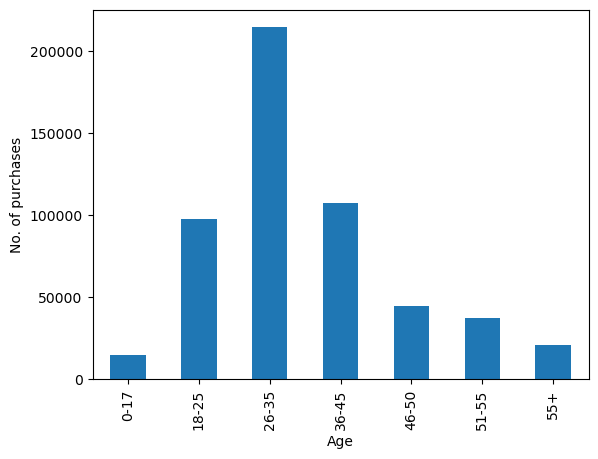

In [30]:
df.groupby('Age')['Purchase'].size().plot(kind='bar' , ylabel='No. of purchases')

Graph above shows that no. Purchases made by each age group

In [31]:
age_data = pd.DataFrame(df[df['Age']=='0-17']['Product_Category_1'].groupby(by=df[df['Age']=='0-17']['Product_Category_1'].values).count())

<Axes: >

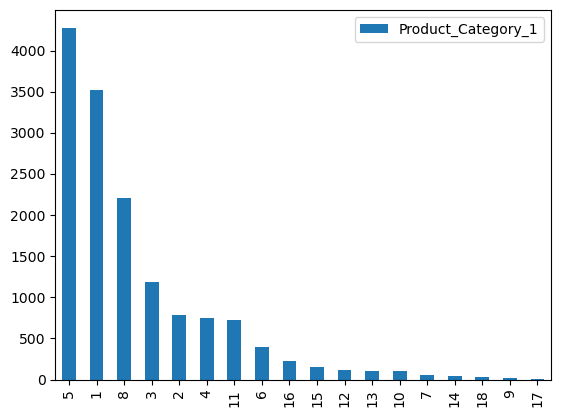

In [32]:
age_data.sort_values(by='Product_Category_1' , ascending=False).plot(kind='bar')

Graph above shows that in age group of 0-17 product category 5 1 and 8 are popular

<Axes: >

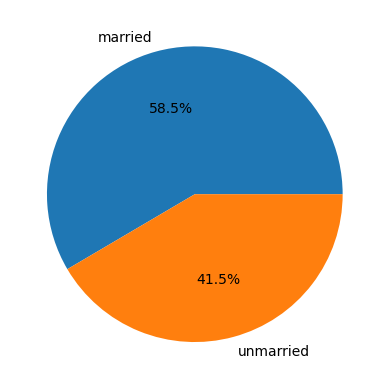

In [33]:
df[df['Gender']=='M'].drop_duplicates('User_ID').groupby(by='Marital_Status').size().plot(kind='pie' , autopct='%.1f%%' , labels={'unmarried' ,'married'})

Graph above shows that 58.5% male customers are unmarried

<Axes: xlabel='Marital_Status', ylabel='count'>

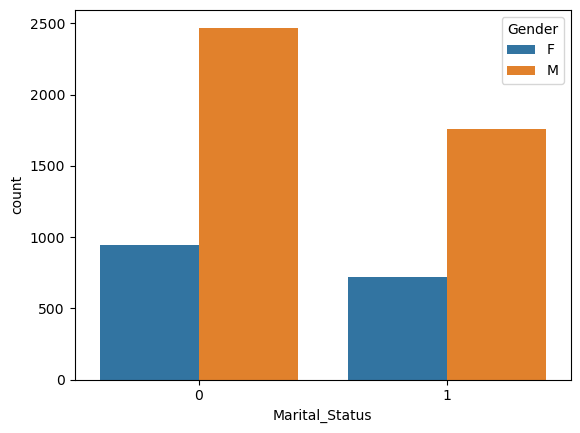

In [34]:
sns.countplot(data=df.drop_duplicates('User_ID') , x='Marital_Status' , hue='Gender')

Graph above shows that married and unmarried male and female

# Analysing Multiple columns

<Axes: xlabel='Age', ylabel='count'>

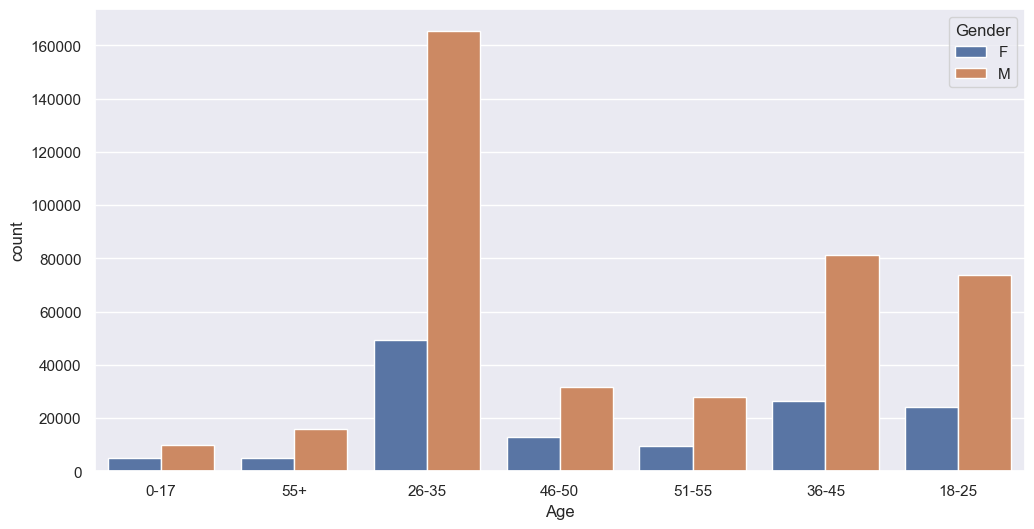

In [35]:
sns.set(rc={'figure.figsize' : (12,6)})
sns.countplot(data=df , x='Age' , hue='Gender')

# Analyzing Multiple cols 

In [36]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<Axes: ylabel='Purchase'>

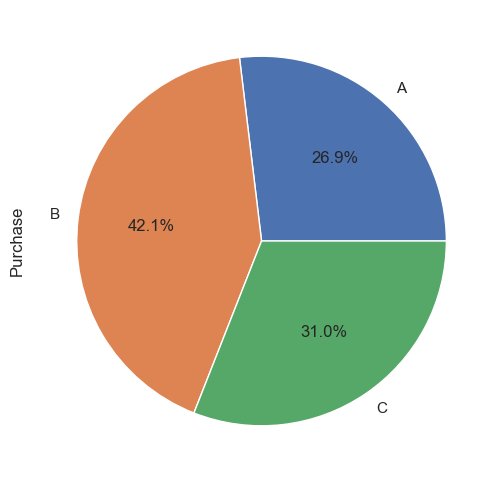

In [37]:
df.groupby(by='City_Category')['Purchase'].count().plot(kind='pie' , autopct='%.1f%%')

<Axes: ylabel='Purchase'>

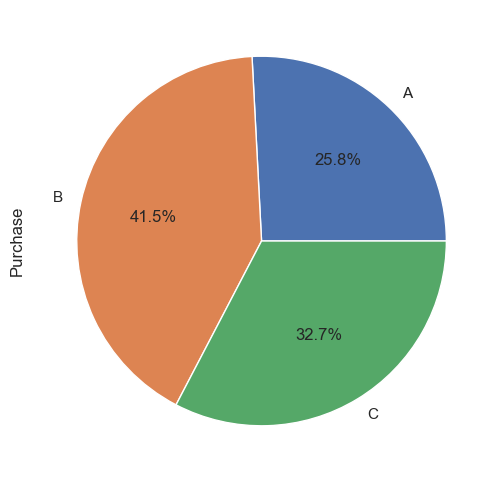

In [38]:
df.groupby(by='City_Category')['Purchase'].sum().plot(kind='pie' , autopct='%.1f%%')

<Axes: xlabel='City_Category', ylabel='count'>

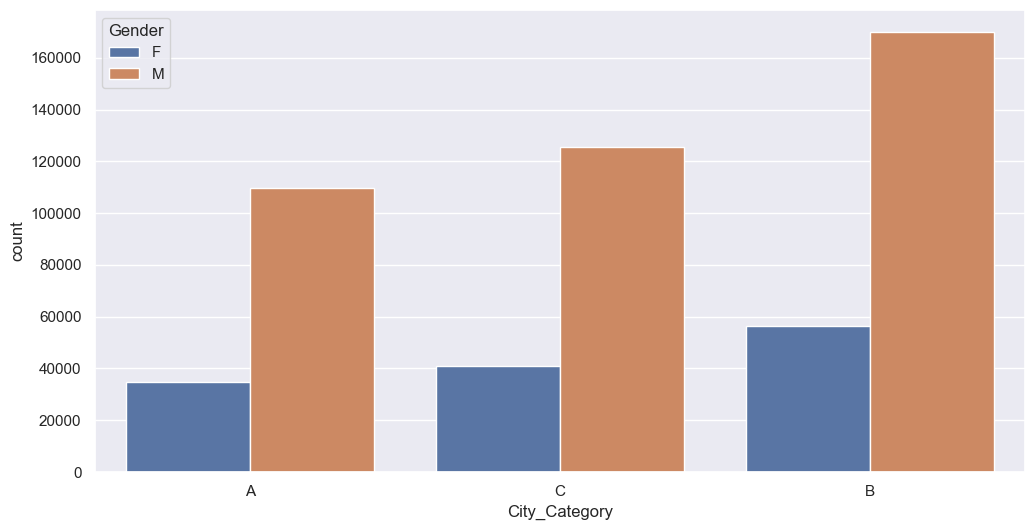

In [39]:
sns.countplot(data=df , x='City_Category' , hue='Gender')

<Axes: xlabel='City_Category', ylabel='count'>

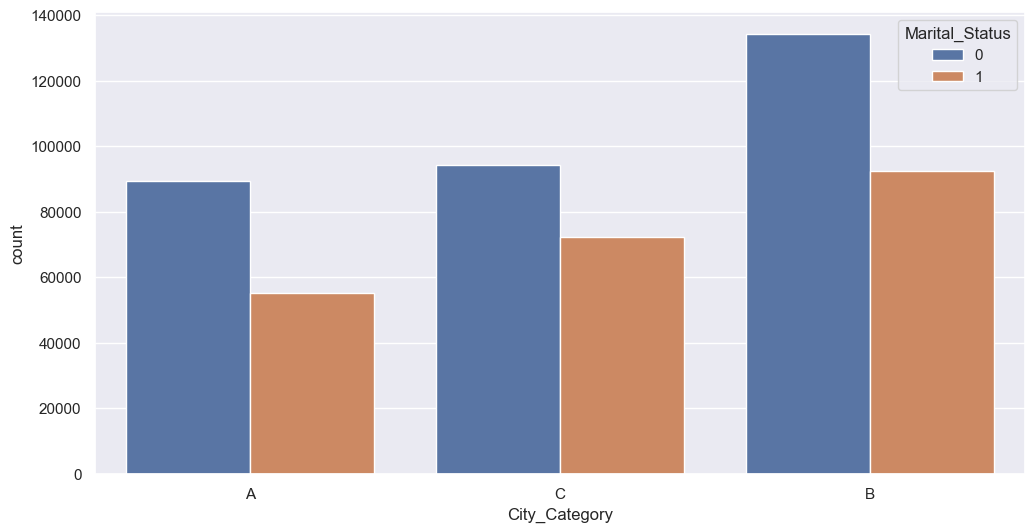

In [40]:
sns.countplot(data=df , x='City_Category' , hue='Marital_Status')

<Axes: xlabel='Age', ylabel='count'>

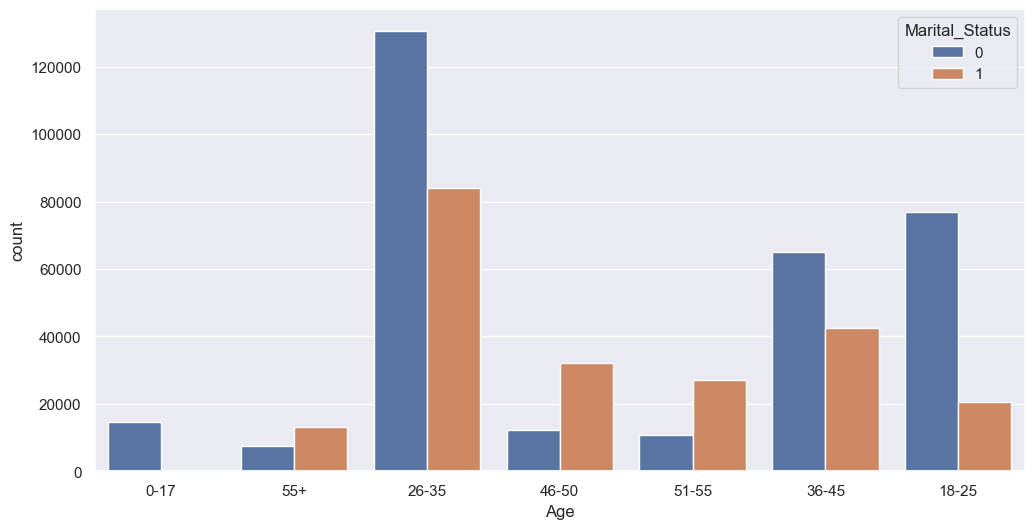

In [41]:
sns.countplot(data=df , x='Age' , hue='Marital_Status')

# Occupation and product Analysis

In [42]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

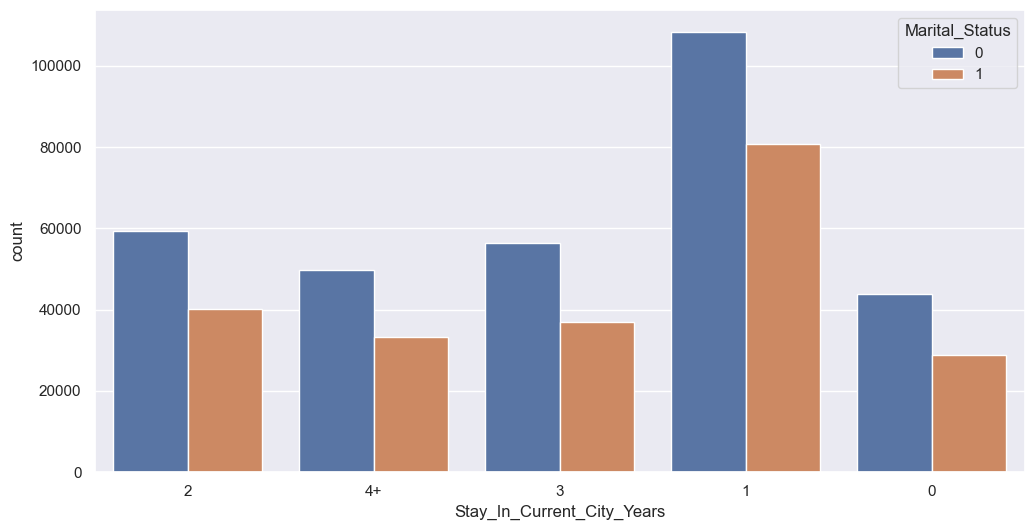

In [43]:
sns.countplot(data=df , x="Stay_In_Current_City_Years" , hue='Marital_Status' )

-> Graph shows that customers who live for 1 year in a city are target audience

-> ummaried customer also have a good purchasing power 

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

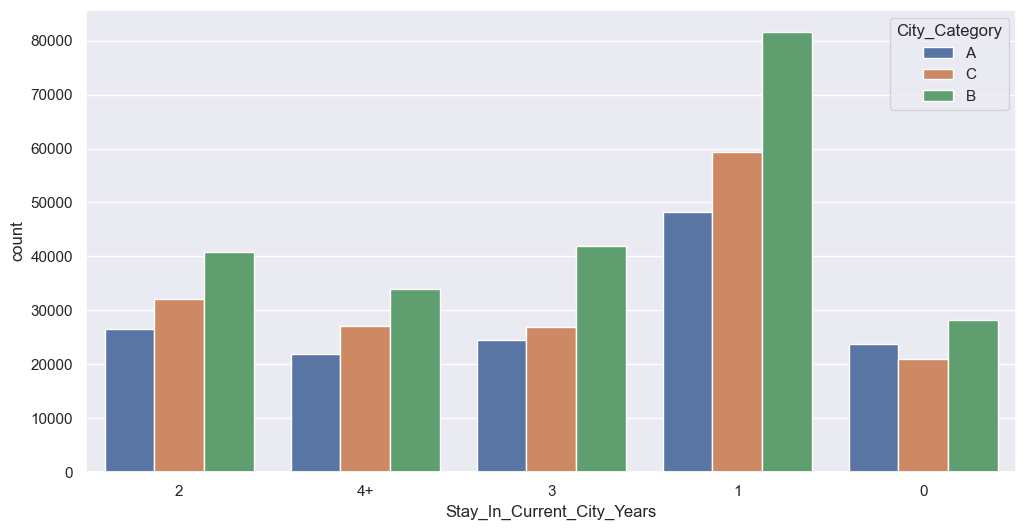

In [44]:
sns.countplot(data=df , x="Stay_In_Current_City_Years" , hue='City_Category' )

-> customer from city B and living there for one year are target audience 

<Axes: xlabel='Occupation'>

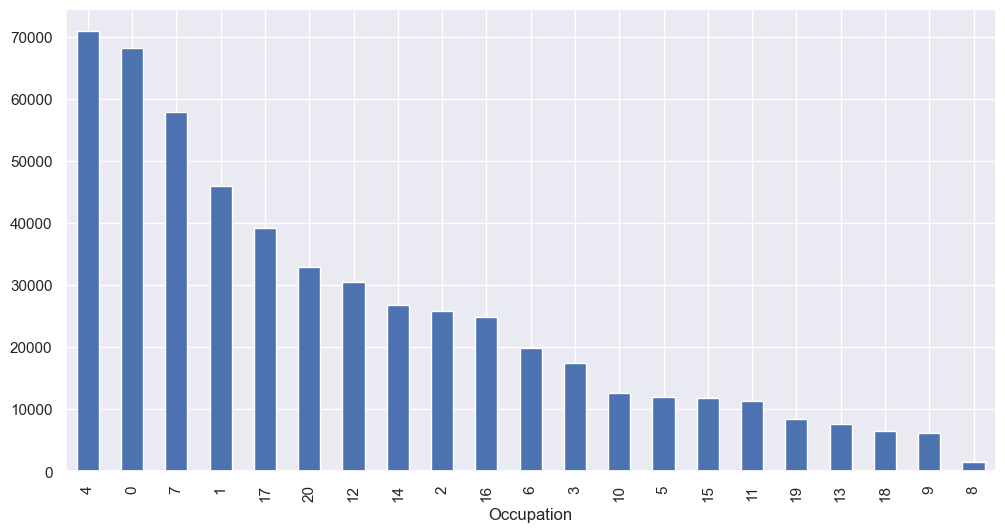

In [45]:
df.groupby(by='Occupation').size().sort_values(ascending=False).plot(kind='bar')

-> Graph above shows that people from occupation 4 are buying more products 

<Axes: xlabel='Occupation', ylabel='count'>

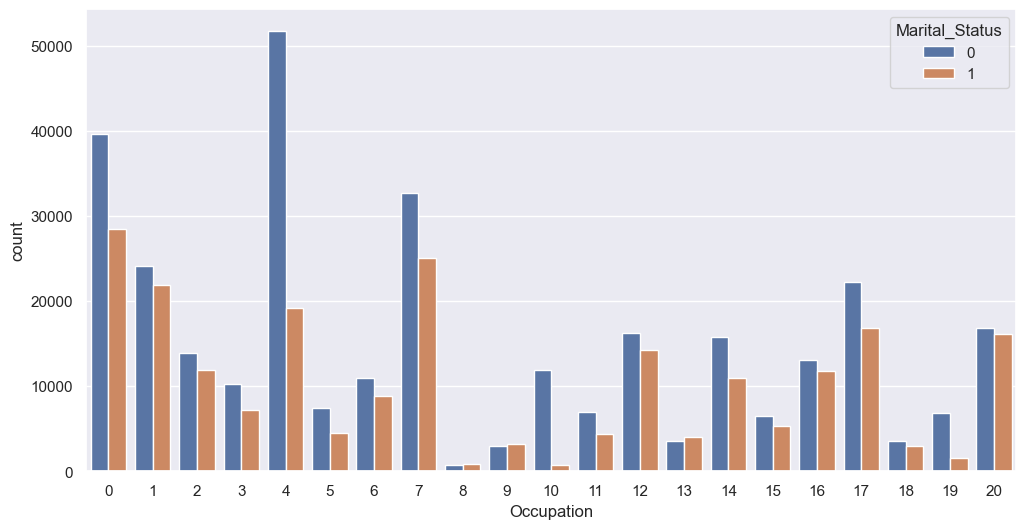

In [46]:
sns.countplot(data=df , x='Occupation' , hue='Marital_Status')

-> Graph shows that unmarried customers hold more purchasing power 

<Axes: xlabel='Occupation', ylabel='count'>

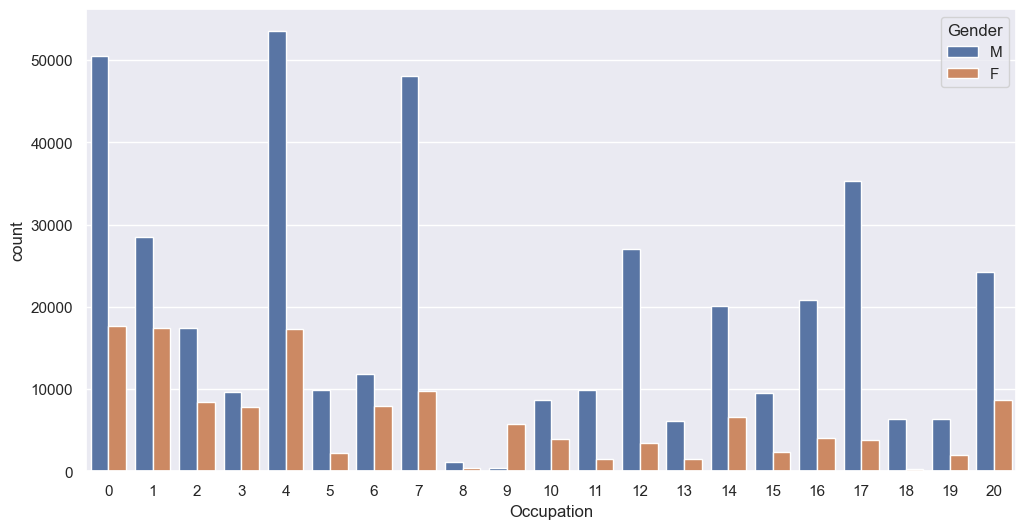

In [47]:
sns.countplot(data=df , x='Occupation' , hue='Gender')

-> occupation 9 is dominated by females

<Axes: xlabel='Occupation'>

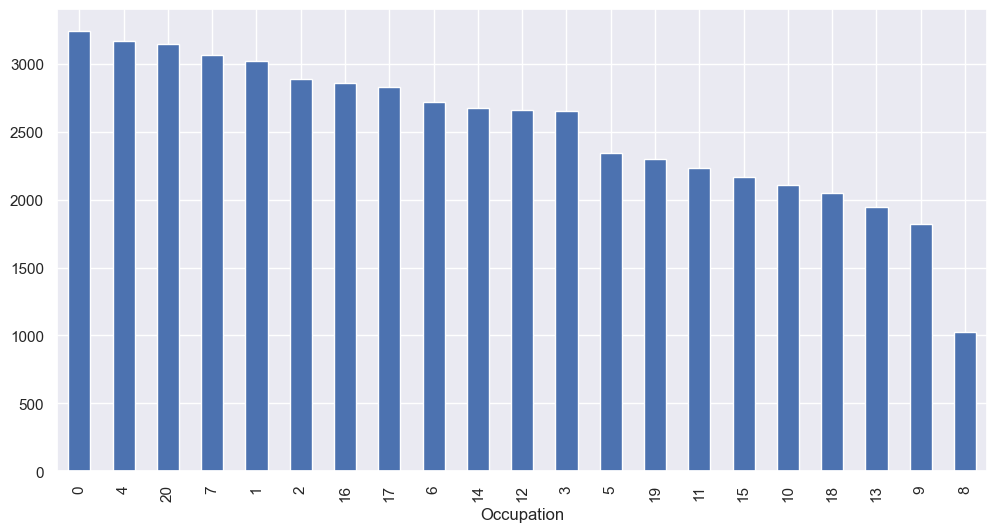

In [48]:
df.groupby(by='Occupation')['Product_ID'].nunique().sort_values(ascending=False).plot(kind='bar')

-> Occupation 0's customers are buying more unique products 

<Axes: xlabel='Product_Category_1'>

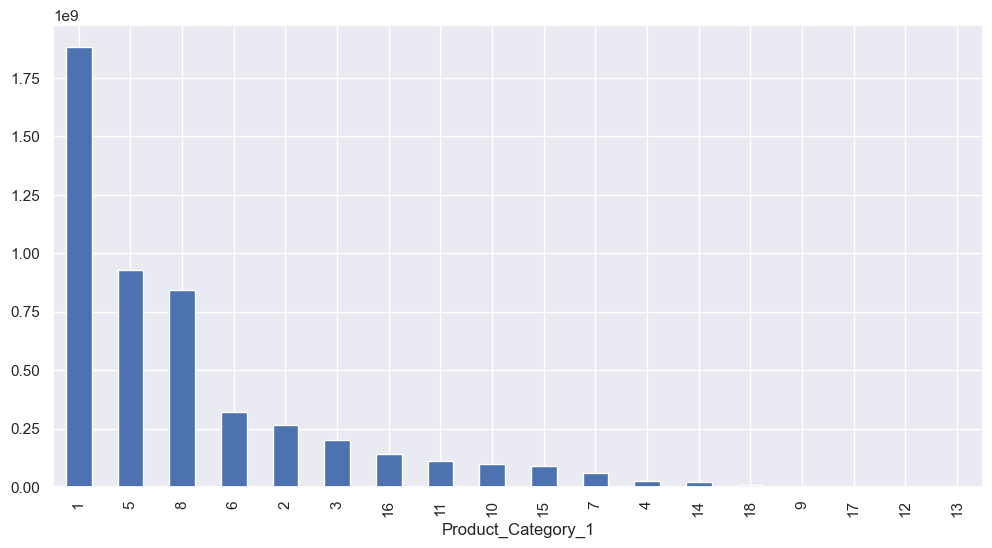

In [49]:
df.groupby(by='Product_Category_1')['Purchase'].sum().sort_values(ascending=False).plot(kind='bar')

-> Money spent on product 1 was the most 

<Axes: xlabel='Product_Category_1'>

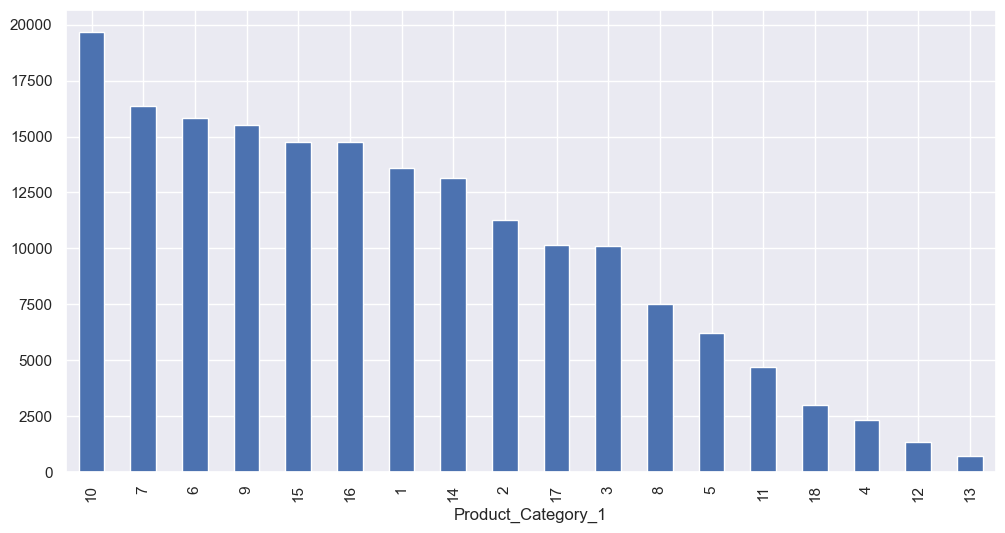

In [50]:
df.groupby(by='Product_Category_1')['Purchase'].mean().sort_values(ascending=False).plot(kind='bar')

-> Product Category 10 is the most expensive category

<Axes: xlabel='Product_ID'>

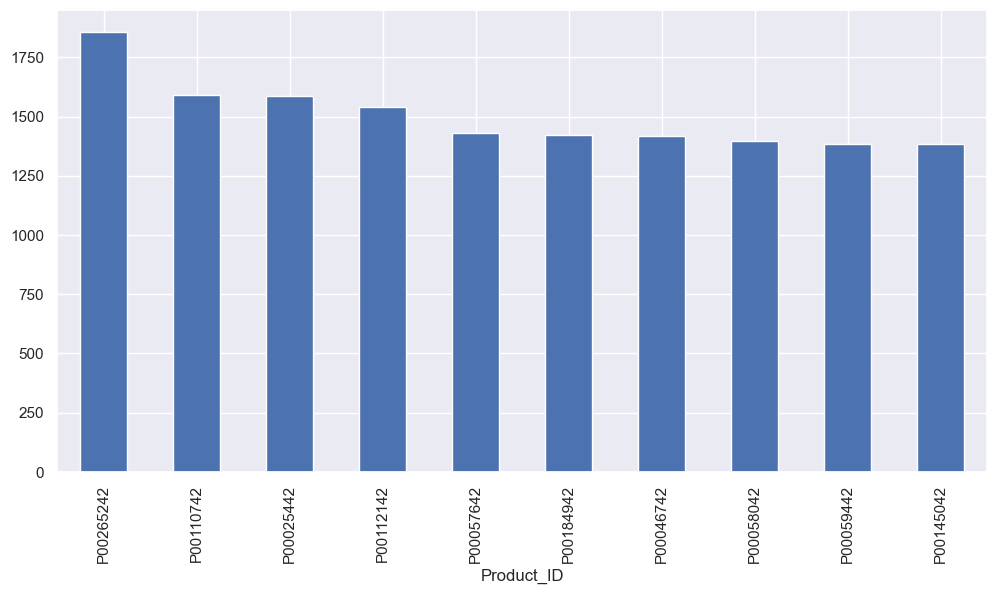

In [51]:
df['Product_ID'].value_counts().sort_values(ascending=False).nlargest(10).plot(kind='bar')

-> Product P00265242 is the most selling product 

# Combining gender and marital status 

In [52]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [53]:
df_male = df[df['Gender']=='M']

<Axes: ylabel='Purchase'>

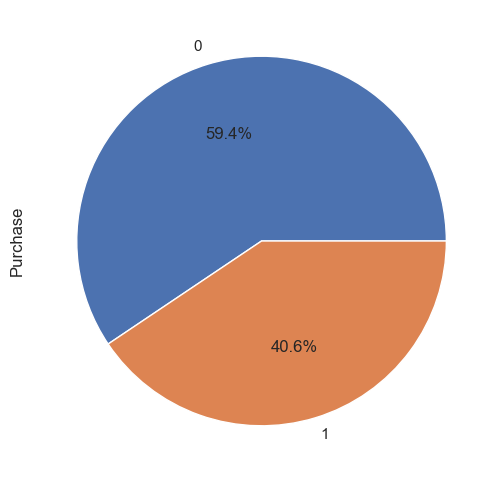

In [56]:
df_male.groupby('Marital_Status')['Purchase'].size().plot(kind='pie' , autopct='%.1f%%')

In [59]:
## adding a new column
df['Gender_Marriage'] = df['Gender'] + '_' +df['Marital_Status'].astype(str)

<Axes: xlabel='Gender_Marriage'>

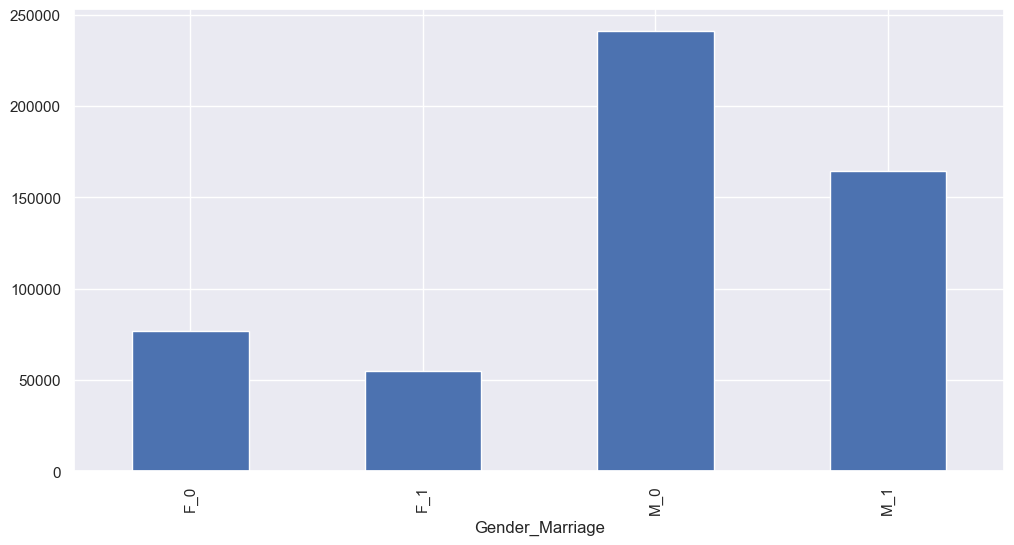

In [63]:
df.groupby('Gender_Marriage')['Purchase'].size().plot(kind='bar')

<Axes: xlabel='City_Category', ylabel='count'>

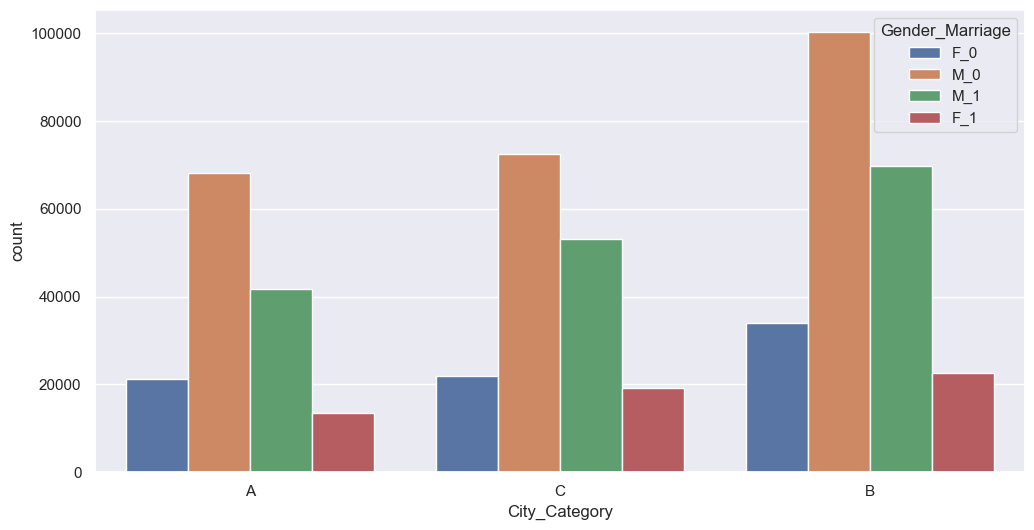

In [64]:
sns.countplot(data=df , x='City_Category' , hue='Gender_Marriage')

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

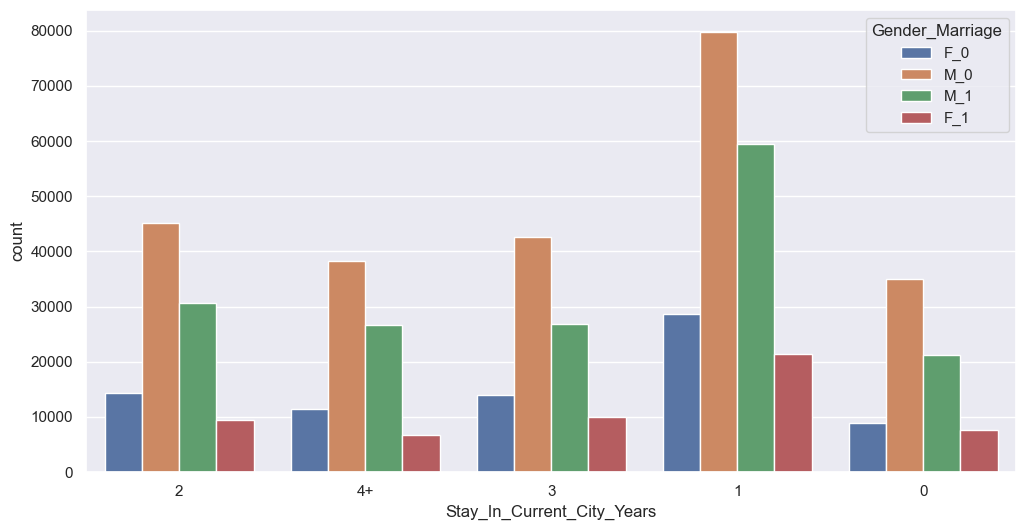

In [66]:
sns.countplot(data=df , x='Stay_In_Current_City_Years' , hue='Gender_Marriage')

<Axes: xlabel='Product_Category_1', ylabel='count'>

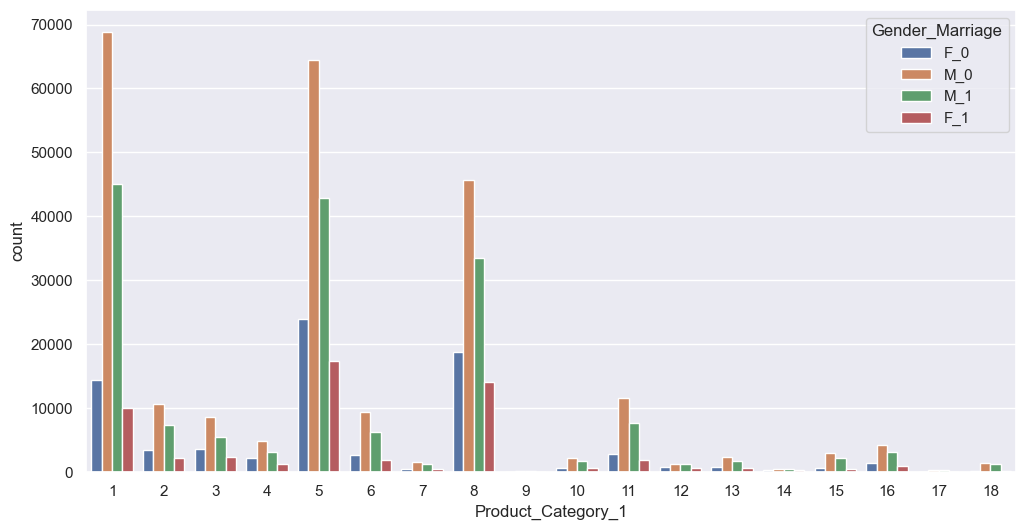

In [67]:
sns.countplot(data=df , x='Product_Category_1' , hue='Gender_Marriage')

<Axes: xlabel='Age', ylabel='count'>

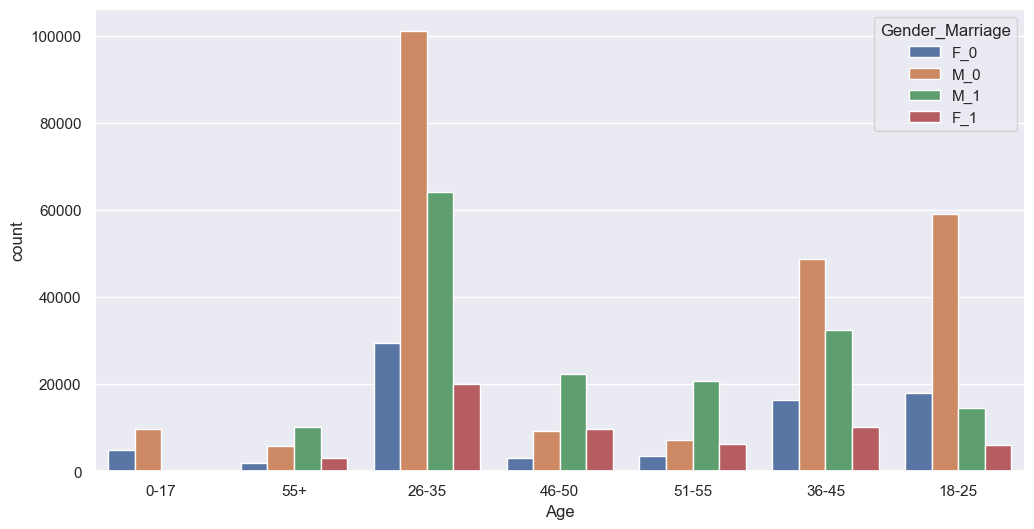

In [68]:
sns.countplot(data=df , x='Age' , hue='Gender_Marriage')

These all graphs above categorizes every data in 4 part married male , unmarried male , married female , unmarried female